# Extracting Images from the Seville Dataset and Generating a Protocol

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns
import imageProc as pr

sns.set_context('talk')
%matplotlib inline
from stimGen import generateSingleSpotPan, plotPanorama, plotPanoramaStretch, createMovie

In [2]:
screenMinDist = 4.0 #cm (r_min in Fig1 S1)
screenMaxDist = 5.5 #cm (r_max in Fig1 S1)

topScreenHeight = 2.5 #cm
bottomScreenHeight = 7 #cm

alpha_rmin = (180/np.pi) * np.arctan( topScreenHeight / screenMinDist)
alpha_rmax = (180/np.pi) * np.arctan( topScreenHeight / screenMaxDist)

print("The screen spans an angle from {} to {} above the horizon line.".format(alpha_rmax, alpha_rmin))

The screen spans an angle from 24.443954780416536 to 32.005383208083494 above the horizon line.


Set `no-ball` to `True` so you can generate appropriate sized scenes

In [3]:
no_ball = True

In [4]:
if not no_ball:
    ballRad = 4.65 # treadmill ball radius [mm]
    flyEyeAboveBall = 1 # height of eye above ball surface [mm]
    print('Angle visible below horizon line:',90-(180/np.pi)*np.arcsin(ballRad/(flyEyeAboveBall+ballRad)))
else:
    beta_rmin = (180/np.pi) * np.arctan( bottomScreenHeight / screenMinDist)
    beta_rmax = (180/np.pi) * np.arctan( bottomScreenHeight / screenMaxDist)
    print("The screen spans an angle from {} to {} below the horizon line.".format(beta_rmax, beta_rmin))

The screen spans an angle from 51.84277341263094 to 60.25511870305777 below the horizon line.


## Extracting Images

In [5]:
plotFolder = "plots/sevilleData/"

In [6]:
zAnt = 0.01 #height of ant in m

In [7]:
dWorld = np.clip(pr.extractWorld("datasets/seville/world5000_gray.mat"), 0, None)

In [8]:
dRoutes, nframes = pr.extractRoutes("datasets/seville/AntRoutes.mat",zAnt)

## Plot Top View of the Route

In [9]:
rt = 'Ant1_Route1'
nframes = nframes-np.sum(np.isnan(dRoutes.sel(routes=rt)).sum(axis=1)>0).values

In [10]:
frame = 250

Specify field of view, angular resolution and visibility

In [11]:
visibility = 1 #in m
hfovDeg = 288 #deg
resDeg = 0.1 #deg
upDeg = alpha_rmax #deg
downDeg = -beta_rmax #deg

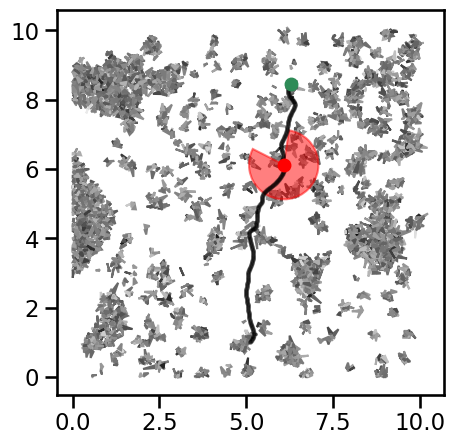

In [12]:
pr.top_view(rt, frame, visibility, dWorld, dRoutes, hfovDeg);
#plt.savefig(plotFolder+"sample_route.png",dpi=300,bbox_inches = 'tight')

## Plot Scene from Ant PoV

Generate scene from the above parameters.

In [13]:
scene = pr.generateScene(rt, frame, visibility, dWorld, dRoutes, hfovDeg, resDeg, upDeg, downDeg, zAnt, invert=False, normalize=False, equalize=False); 

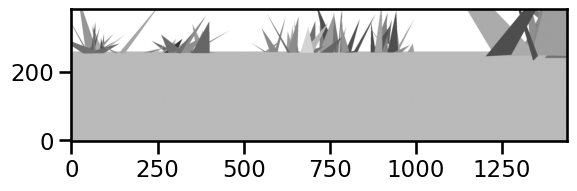

In [15]:
plt.imshow(scene,cmap='gray',origin='lower', vmin=0, vmax=1);

## Generate Walkthrough

In [16]:
snapshots = 20

In [17]:
scenes_unflipped, frames = pr.walkThrough(nframes, rt, snapshots,
               visibility, dWorld, dRoutes, hfovDeg, resDeg, upDeg, downDeg, zAnt,
               animate=False, save=False, plotFolder=plotFolder, invert=False, normalize=False, equalize=True);

In [18]:
scenes_flipped, _ =  pr.walkThrough(nframes, rt, snapshots,
               visibility, dWorld, dRoutes, hfovDeg, resDeg, upDeg, downDeg, zAnt,
               animate=False, save=False, plotFolder=plotFolder, invert=True, normalize=False, equalize=True);

In [19]:
scenes = np.array([scenes_flipped.T, scenes_unflipped.T]).T.reshape(scenes_flipped.shape[0], scenes_flipped.shape[1], -1)
np.random.seed(0)
shuffle = np.random.permutation(scenes.shape[2])
scenes = scenes[:,:,shuffle]

## Add Stimuli

In [20]:
black_white = np.max(scenes_unflipped,axis=2)<1

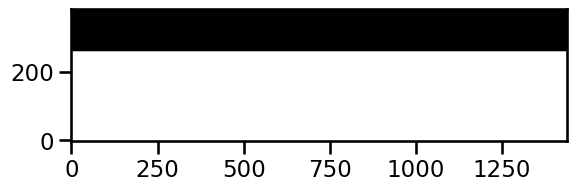

In [21]:
plt.imshow(black_white,cmap='gray',origin='lower', vmin=0, vmax=1);

In [22]:
white_black = 1-black_white
white = np.ones_like(white_black)
black = np.zeros_like(white_black)

In [23]:
stimuliSet = np.zeros((np.shape(scenes)[0], np.shape(scenes)[1], np.shape(scenes)[2]+4))
stimuliSet[...,0] = black_white
stimuliSet[...,1] = white_black
stimuliSet[...,2] = black
stimuliSet[...,3] = white
stimuliSet[...,4:] = scenes

maxBit = 255
stimuliSet = (stimuliSet*maxBit).astype(np.uint8)

In [24]:
%%capture
anim = createMovie(stimuliSet.T,scenes.shape[0],scenes.shape[1],maxBit)

In [25]:
from IPython.display import HTML
HTML(anim.to_jshtml())

## Save movie as a series of images

In [26]:
seperatorDuration = 2 #seconds
frameDuration = 2 #seconds
repeats = 5 #how many times to repeat the full set of stimuli

In [27]:
video_name = "flash_nScenes-"+str(snapshots+4)+"_seperatorDur-"+str(
    seperatorDuration)+"_frameDur"+str(frameDuration)

In [28]:
import pandas as pd

In [29]:
imageDf = pd.DataFrame({
    'filename': [f"frame_{i:03d}.png" for i in range(np.shape(stimuliSet)[2])],
    'repeat': [repeats for i in range(np.shape(stimuliSet)[2])],
})

In [30]:
from os import sep
from pathlib import Path
Path(sep.join(["movies",video_name])).mkdir(parents=True, exist_ok=True)

In [31]:
import imageio
textures = []
for i in range(len(imageDf)):
    imageio.imwrite(sep.join(["movies",video_name,imageDf.iloc[i]['filename']]), np.flip(stimuliSet[:,:,i], axis=0))
    textures.append(imageDf.iloc[i]['filename'])



In [32]:
import json
temp = {
    'durationSecs': frameDuration+seperatorDuration,
    'textures': textures*repeats,
    'separatorDurationSecs': seperatorDuration,
}
json_name = sep.join(["movies",video_name,'start.json'])
with open(json_name, 'w') as json_file:
    json_file.write(json.dumps(temp))